In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
data = pd.read_csv("cleaned_data.csv")

In [4]:
data["Age_Band"] = pd.cut(
    data["Age"],
    bins=[0, 8, 12, 16],
    labels=["Young Kids", "Pre-Teens", "Teenagers"]
)
print(data["Age_Band"].value_counts())

Age_Band
Teenagers     3546
Pre-Teens     3495
Young Kids     912
Name: count, dtype: int64


In [7]:
data["Age_Band"] = pd.cut(
    data["Age"],
    bins=[0,10,13,16,20],
    labels=["Child","Pre-Teen","Teen","Older Teen"]
)

data[["Age","Age_Band"]].head()

,Age,Age_Band
0,14,Teen
1,11,Pre-Teen
2,18,Older Teen
3,15,Teen
4,12,Pre-Teen


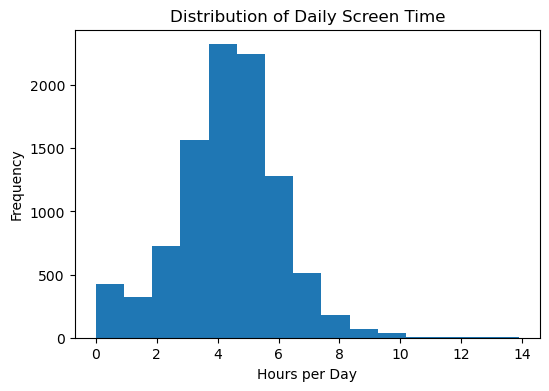

In [9]:
#UNIVARIATE VISUAL ANALYSIS
#Distribution of Daily Screen Time (Histogram)
plt.figure(figsize=(6,4))
plt.hist(data["Avg_Daily_Screen_Time_hr"], bins=15)
plt.title("Distribution of Daily Screen Time")
plt.xlabel("Hours per Day")
plt.ylabel("Frequency")
plt.show()

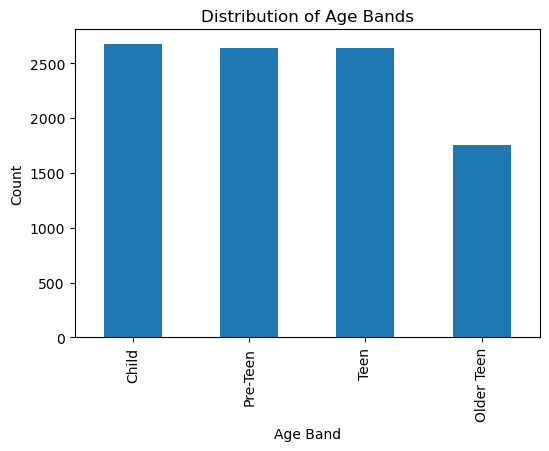

In [11]:
#Distribution of Age Bands (Bar Chart)
plt.figure(figsize=(6,4))
data["Age_Band"].value_counts().plot(kind="bar")
plt.title("Distribution of Age Bands")
plt.xlabel("Age Band")
plt.ylabel("Count")
plt.show()

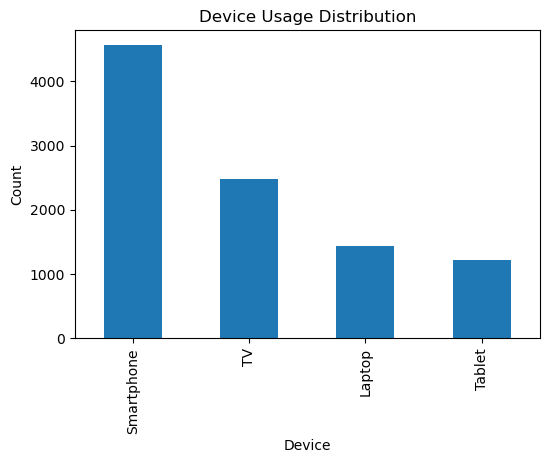

In [13]:
#Distribution of Device Usage (Bar Chart)
plt.figure(figsize=(6,4))
data["Primary_Device"].value_counts().plot(kind="bar")
plt.title("Device Usage Distribution")
plt.xlabel("Device")
plt.ylabel("Count")
plt.show()

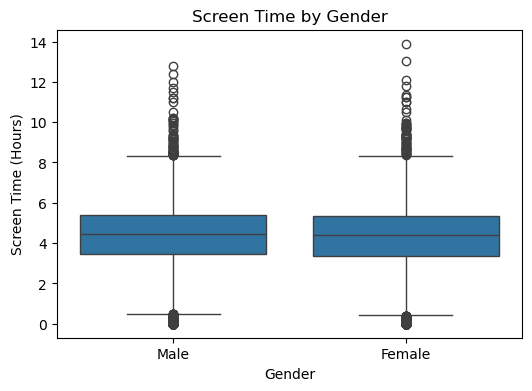

In [15]:
#BIVARIATE VISUAL ANALYSIS⃣
#Screen Time by Gender (Boxplot)
plt.figure(figsize=(6,4))
sns.boxplot(x="Gender", y="Avg_Daily_Screen_Time_hr", data=data)

plt.title("Screen Time by Gender")
plt.xlabel("Gender")
plt.ylabel("Screen Time (Hours)")
plt.show()

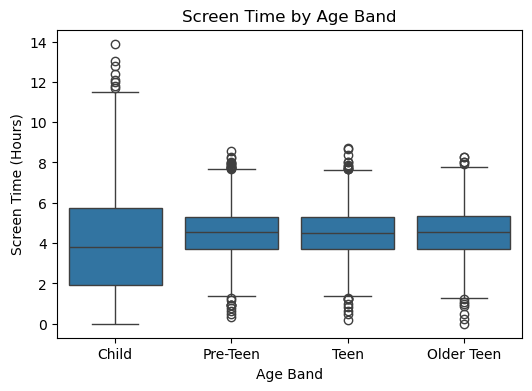

In [17]:
#Screen Time by Age Band (Boxplot)
plt.figure(figsize=(6,4))
sns.boxplot(x="Age_Band", y="Avg_Daily_Screen_Time_hr", data=data)

plt.title("Screen Time by Age Band")
plt.xlabel("Age Band")
plt.ylabel("Screen Time (Hours)")
plt.show()

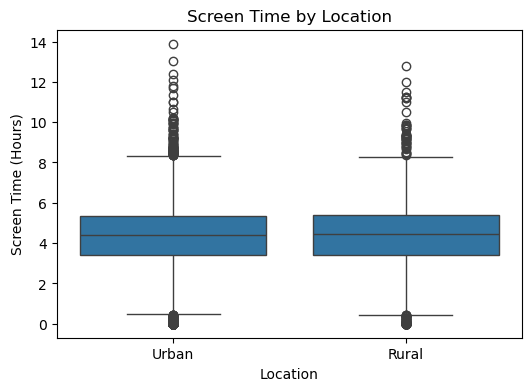

In [19]:
#Screen Time by Location Type (Urban/Rural)
plt.figure(figsize=(6,4))
sns.boxplot(x="Urban_or_Rural", y="Avg_Daily_Screen_Time_hr", data=data)

plt.title("Screen Time by Location")
plt.xlabel("Location")
plt.ylabel("Screen Time (Hours)")
plt.show()

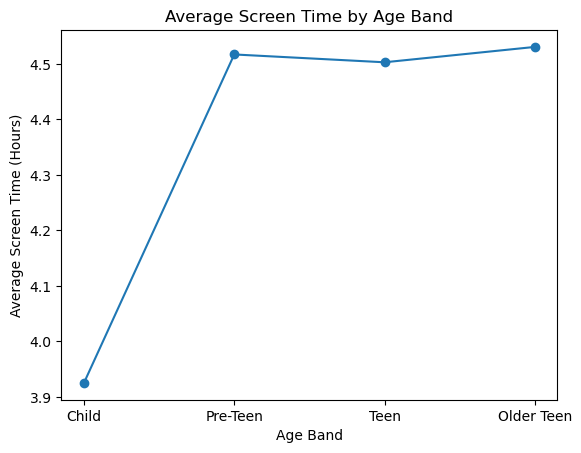

In [23]:
#Line Plot (Trend of Screen Time Across Age Bands)
avg_screen = data.groupby("Age_Band", observed=False)["Avg_Daily_Screen_Time_hr"].mean()

plt.plot(avg_screen.index, avg_screen.values, marker="o")

plt.title("Average Screen Time by Age Band")
plt.xlabel("Age Band")
plt.ylabel("Average Screen Time (Hours)")
plt.show()

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

data = pd.read_csv("cleaned_data.csv")

In [31]:
#Create Required Derived Fields
#Age Bands
data["Age_Band"] = pd.cut(
    data["Age"],
    bins=[5,8,12,16],
    labels=["Young Kids","Pre-Teens","Teenagers"]
)

In [33]:
data["Day_Type"] = np.random.choice(["Weekday","Weekend"], size=len(data))

In [35]:
data["Activity_Type"] = data["Educational_to_Recreational_Ratio"].apply(
    lambda x: "Education Focused" if x >= 0.5 else "Recreation Focused"
)

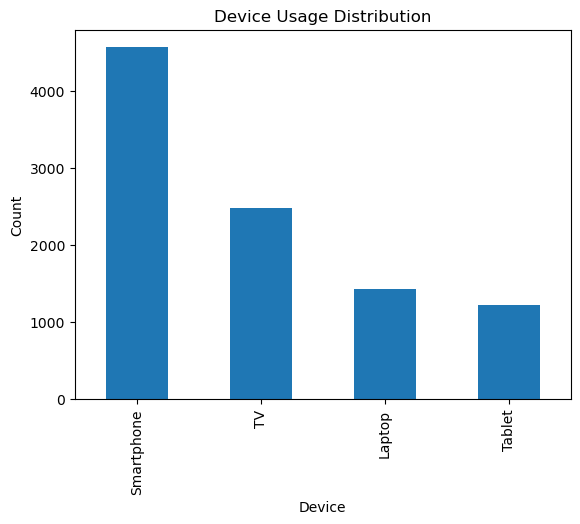

In [37]:
#DEVICE MIX ANALYSIS
#Device Usage Distribution
data["Primary_Device"].value_counts().plot(kind="bar")
plt.title("Device Usage Distribution")
plt.xlabel("Device")
plt.ylabel("Count")
plt.show()

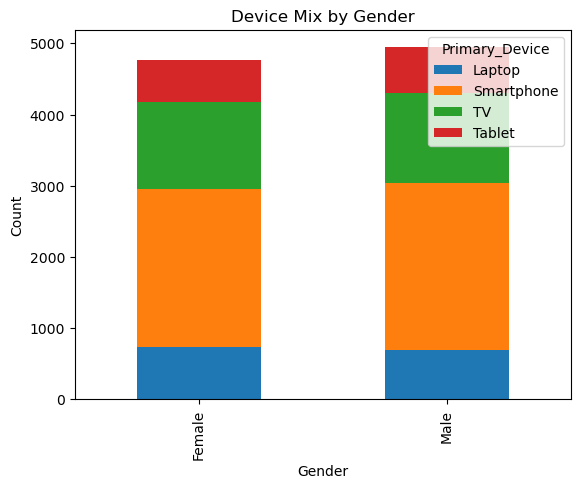

In [39]:
#Device Usage by Gender
pd.crosstab(data["Gender"], data["Primary_Device"]).plot(kind="bar", stacked=True)

plt.title("Device Mix by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

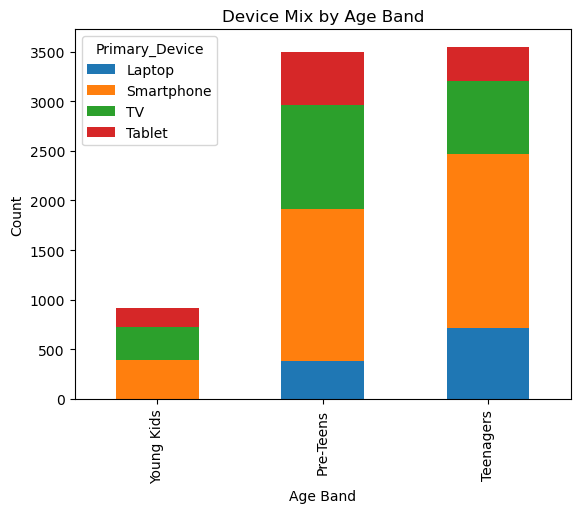

In [41]:
#Device Usage by Age Band
pd.crosstab(data["Age_Band"], data["Primary_Device"]).plot(kind="bar", stacked=True)

plt.title("Device Mix by Age Band")
plt.xlabel("Age Band")
plt.ylabel("Count")
plt.show()

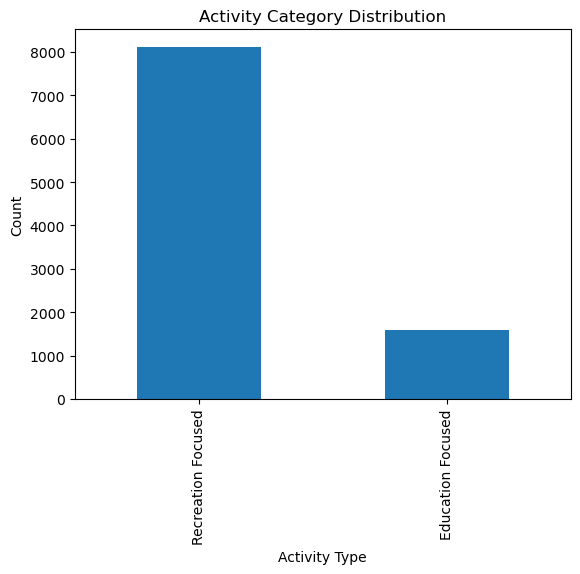

In [43]:
#ACTIVITY CATEGORY ANALYSIS
#Activity Type Distribution
data["Activity_Type"].value_counts().plot(kind="bar")

plt.title("Activity Category Distribution")
plt.xlabel("Activity Type")
plt.ylabel("Count")
plt.show()

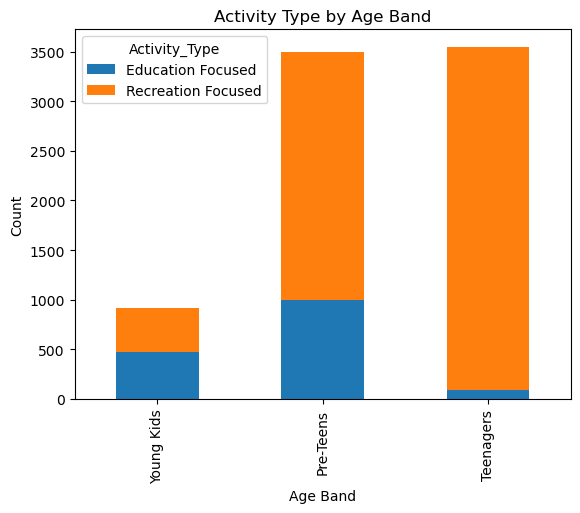

In [45]:
#Activity Type by Age Band
pd.crosstab(data["Age_Band"], data["Activity_Type"]).plot(kind="bar", stacked=True)

plt.title("Activity Type by Age Band")
plt.xlabel("Age Band")
plt.ylabel("Count")
plt.show()

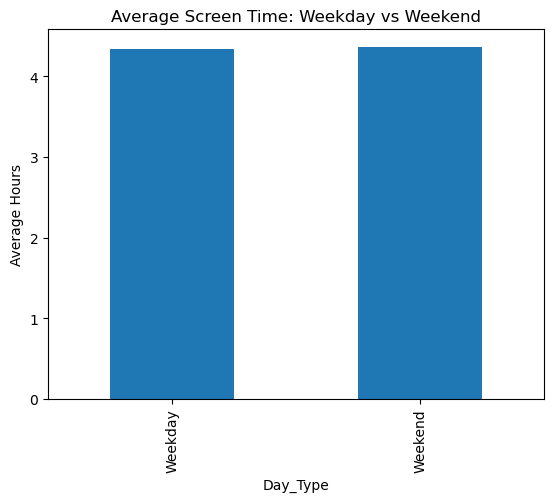

In [47]:
#WEEKDAY vs WEEKEND ANALYSIS
#Average Screen Time: Weekday vs Weekend
data.groupby("Day_Type")["Avg_Daily_Screen_Time_hr"].mean().plot(kind="bar")

plt.title("Average Screen Time: Weekday vs Weekend")
plt.ylabel("Average Hours")
plt.show()

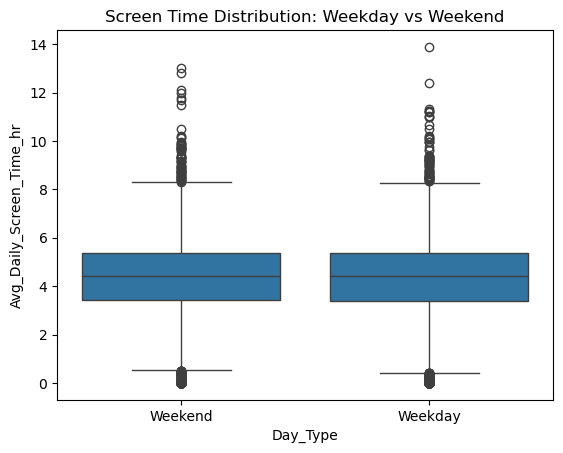

In [49]:
#Screen Time Distribution by Day Type
sns.boxplot(x="Day_Type", y="Avg_Daily_Screen_Time_hr", data=data)

plt.title("Screen Time Distribution: Weekday vs Weekend")
plt.show()

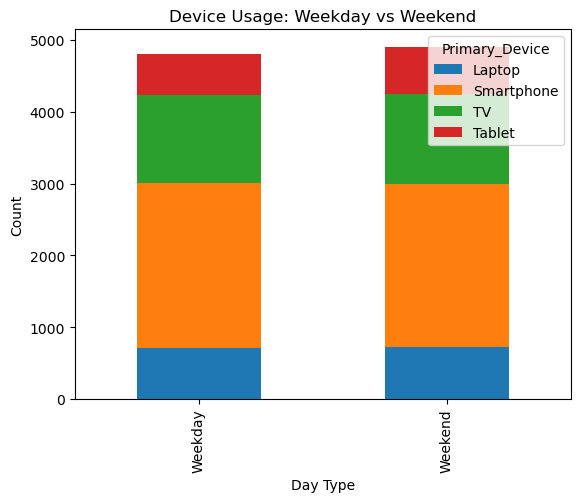

In [51]:
#Device Usage on Weekday vs Weekend
pd.crosstab(data["Day_Type"], data["Primary_Device"]).plot(kind="bar", stacked=True)

plt.title("Device Usage: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Count")
plt.show()

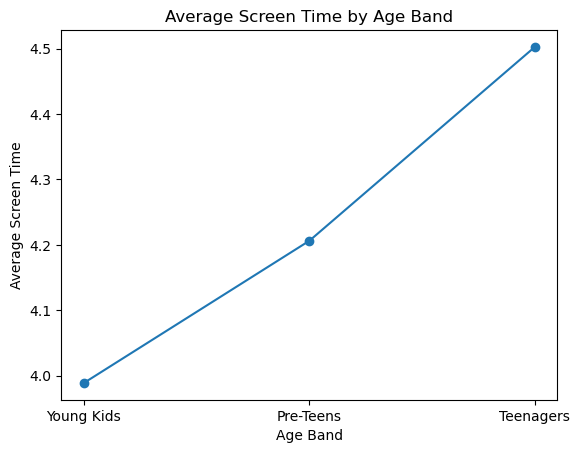

In [53]:
#TIME PATTERN ANALYSIS
#Average Screen Time by Age Band (Line Plot)
avg_screen = data.groupby("Age_Band", observed=False)["Avg_Daily_Screen_Time_hr"].mean()

plt.plot(avg_screen.index, avg_screen.values, marker="o")

plt.title("Average Screen Time by Age Band")
plt.xlabel("Age Band")
plt.ylabel("Average Screen Time")
plt.show()